In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

from src.data_loader import load_stratified_sample
from src.features import engineer_features
from src.analyzer import get_top_n_per_category, summary_pivot, size_interaction

In [3]:
df = load_stratified_sample()
df_reliable = engineer_features(df)

print(f"df: {df.shape}")
print(f"df_reliable: {df_reliable.shape}")

Cache ditemukan, load langsung dari ..\data\wm811k_v2.pkl
Cache ditemukan, load langsung dari ..\data\wm811k_v3_reliable.pkl
df: (811457, 9)
df_reliable: (809424, 25)


In [4]:
top3_per_category = get_top_n_per_category(df_reliable, n=3)
top3_per_category.to_pickle('../data/top3_per_category.pkl')

print(f"top3_per_category: {top3_per_category.shape}")
print(top3_per_category[['density_global', 'density_center', 'density_edge']])

top3_per_category: (27, 7)
                          density_global  density_center  density_edge
failureType_clean                                                     
Center            573           0.727142        0.961776      0.397924
                  1097          0.717783        0.967941      0.366782
                  1959          0.706983        0.964242      0.346021
Donut             4674          0.678411        0.792593      0.561457
                  4640          0.651032        0.641221      0.660517
                  4689          0.637524        0.779555      0.457701
Edge-Loc          6035          0.746124        0.797872      0.683761
                  7851          0.719493        0.713996      0.725469
                  7533          0.719444        0.753311      0.676471
Edge-Ring         13835         0.451005        0.289786      0.632000
                  17890         0.437186        0.282660      0.610667
                  15906         0.432161        0.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

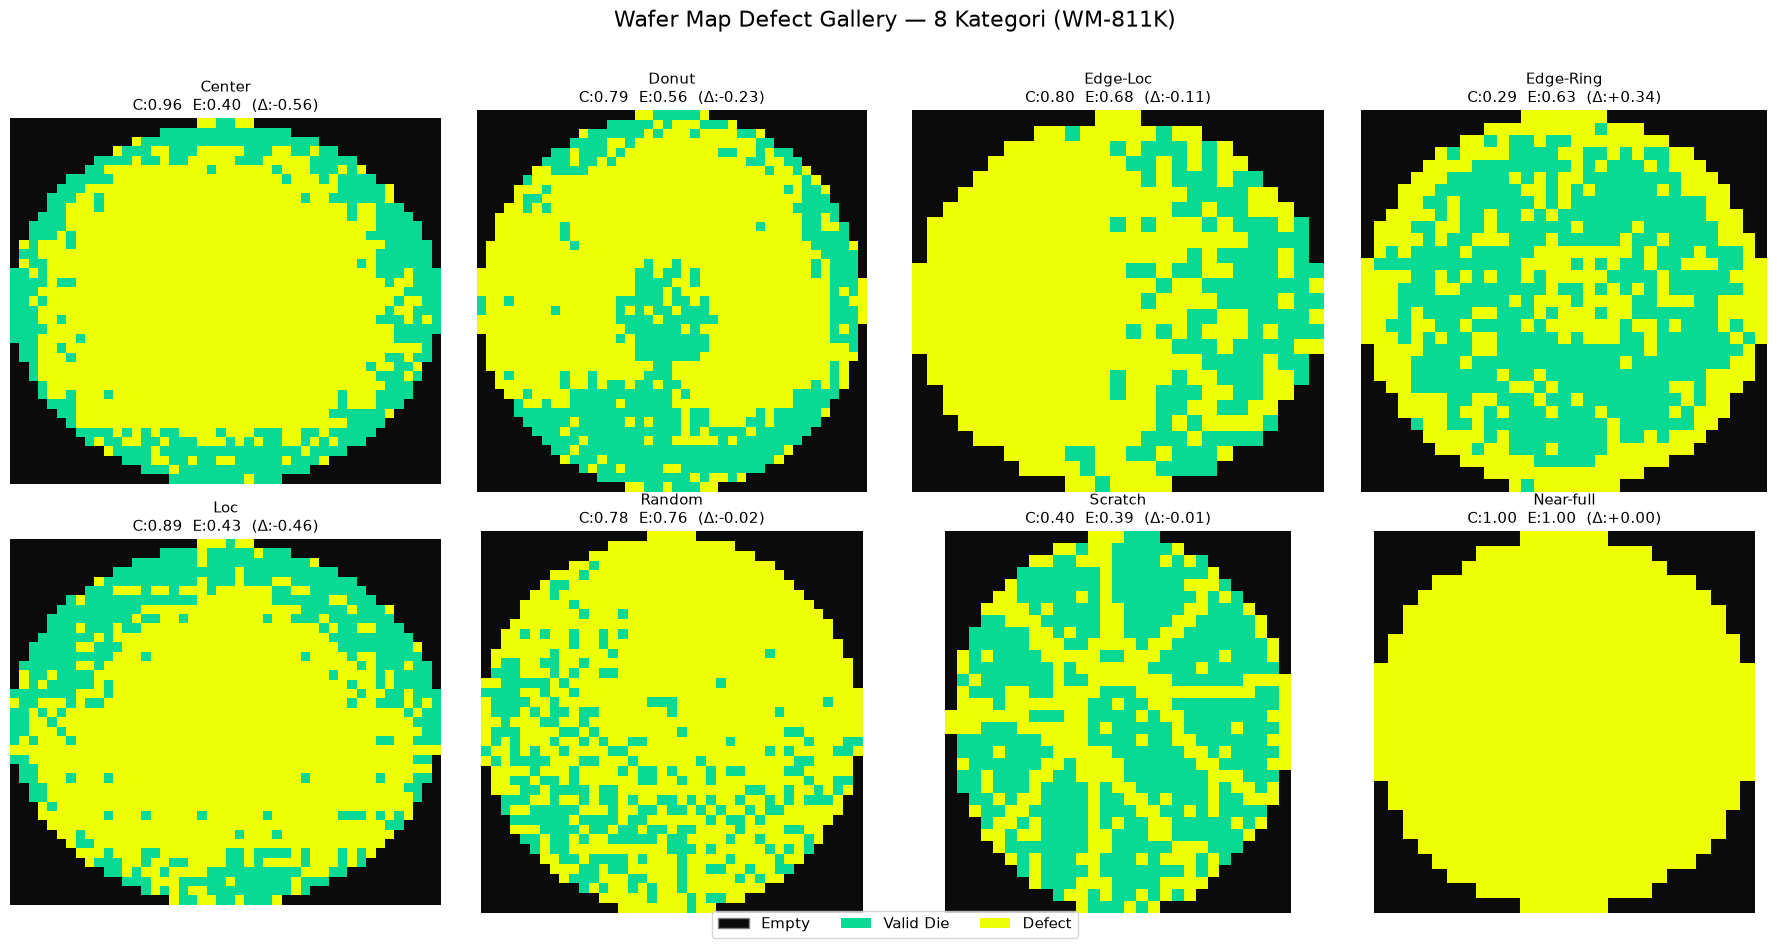

In [6]:
plt.close('all')

categories = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

# Colormap diskrit: 0=Empty, 1=Valid Die, 2=Defect
cmap = ListedColormap(["#0B0B0B", '#08DA94', '#EEFF05'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sample = top3_per_category.loc[cat].iloc[0]  # Opsi A: density tertinggi
    wm = sample['waferMap']

    sns.heatmap(
        wm, cmap=cmap, norm=norm, cbar=False,
        square=True, xticklabels=False, yticklabels=False, ax=axes[i],
    )

    d_center = sample['density_center']
    d_edge = sample['density_edge']
    diff = sample['edge_center_diff']
    axes[i].set_title(
        f"{cat}\nC:{d_center:.2f}  E:{d_edge:.2f}  (\u0394:{diff:+.2f})",
        fontsize=11,
    )

legend_elements = [
    Patch(facecolor="#0B0B0B", edgecolor='gray', label='Empty'),
    Patch(facecolor="#08DA94", label='Valid Die'),
    Patch(facecolor="#EEFF05", label='Defect'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)

fig.suptitle('Wafer Map Defect Gallery \u2014 8 Kategori (WM-811K)', fontsize=16, y=1.02)
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/defect_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

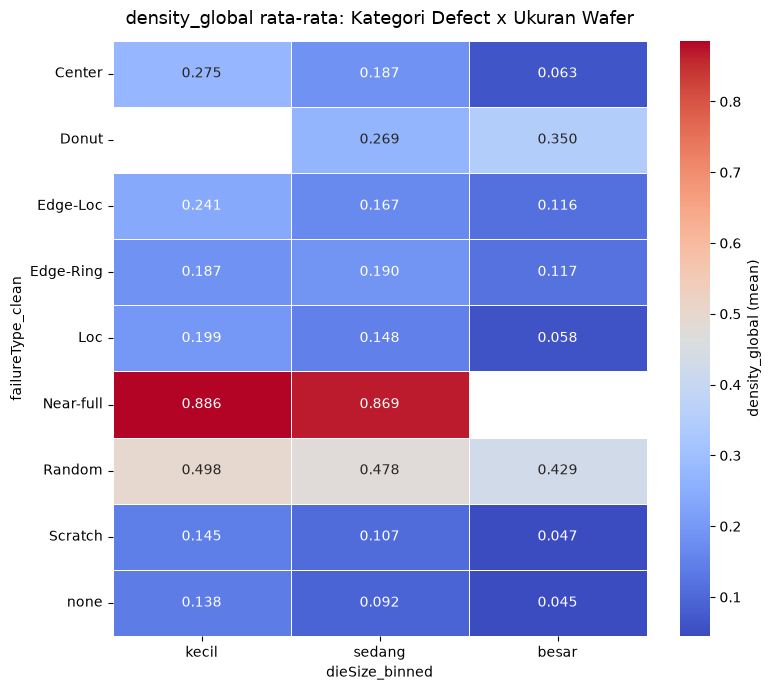

Sel di-mask (n < 30):
failureType_clean  dieSize_binned
Donut              kecil             17
Near-full          besar              2
dtype: int64


In [8]:
# density_global rata-rata per kategori x dieSize_binned.
# Sel dengan n terlalu kecil di-mask, karena mean dari sample kecil
# gampang menyesatkan (lihat catatan Day 13 soal "6 dari 9 kategori
# dengan sample size reliable").

means, counts = size_interaction(df_reliable)

MIN_N = 30  # ambang jumlah baris minimal per sel biar mean-nya reliable
mask = counts < MIN_N

plt.figure(figsize=(8, 7))
sns.heatmap(
    means,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    linewidths=.5,
    cbar_kws={'label': 'density_global (mean)'},
)
plt.title('density_global rata-rata: Kategori Defect x Ukuran Wafer', fontsize=13, pad=12)
plt.xlabel('dieSize_binned')
plt.ylabel('failureType_clean')
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/size_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

masked_cells = counts.where(mask).stack().dropna()
print(f"Sel di-mask (n < {MIN_N}):")
print(masked_cells.astype(int) if len(masked_cells) > 0 else "Tidak ada, semua sel sample-nya cukup.")

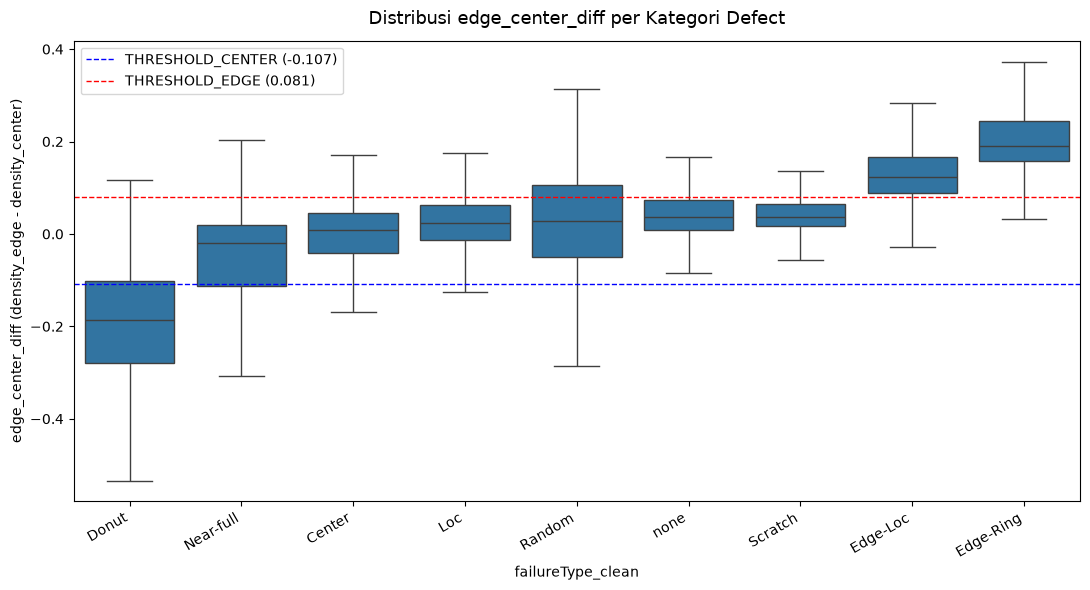

In [9]:
threshold_center = df_reliable.loc[df_reliable['is_center_heavy'], 'edge_center_diff'].max()
threshold_edge = df_reliable.loc[df_reliable['is_edge_heavy'], 'edge_center_diff'].min()

# Urutkan kategori berdasarkan median, biar boxplot kebaca sebagai
order = (
    df_reliable.groupby('failureType_clean', observed=True)['edge_center_diff']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_reliable,
    x='failureType_clean',
    y='edge_center_diff',
    order=order,
    showfliers=False, 
)
plt.axhline(threshold_center, color='blue', linestyle='--', linewidth=1,
            label=f'THRESHOLD_CENTER ({threshold_center:.3f})')
plt.axhline(threshold_edge, color='red', linestyle='--', linewidth=1,
            label=f'THRESHOLD_EDGE ({threshold_edge:.3f})')
plt.legend()
plt.title('Distribusi edge_center_diff per Kategori Defect', fontsize=13, pad=12)
plt.xlabel('failureType_clean')
plt.ylabel('edge_center_diff (density_edge - density_center)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/edge_center_diff_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

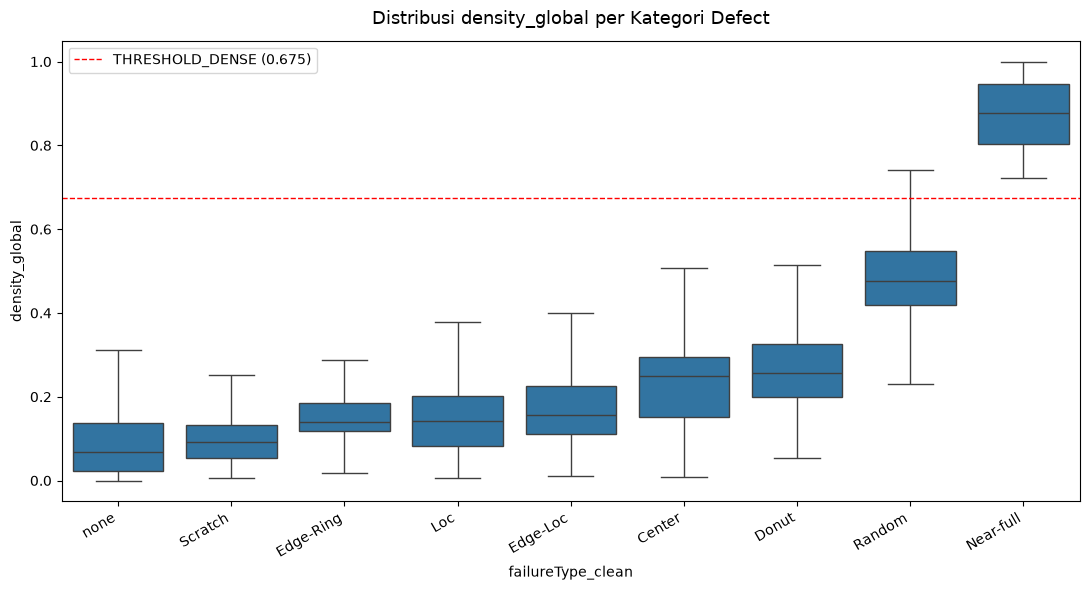

In [10]:
# Distribusi density_global per kategori

threshold_dense = df_reliable.loc[df_reliable['is_globally_dense'], 'density_global'].min()

order_dense = (
    df_reliable.groupby('failureType_clean', observed=True)['density_global']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_reliable,
    x='failureType_clean',
    y='density_global',
    order=order_dense,
    showfliers=False,
)
plt.axhline(threshold_dense, color='red', linestyle='--', linewidth=1,
            label=f'THRESHOLD_DENSE ({threshold_dense:.3f})')
plt.legend()
plt.title('Distribusi density_global per Kategori Defect', fontsize=13, pad=12)
plt.xlabel('failureType_clean')
plt.ylabel('density_global')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/density_global_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Reviewed with defect : 25519
Naive denominator    : 811457     -> 3.14%
Correct denominator  : 172950  -> 14.76%


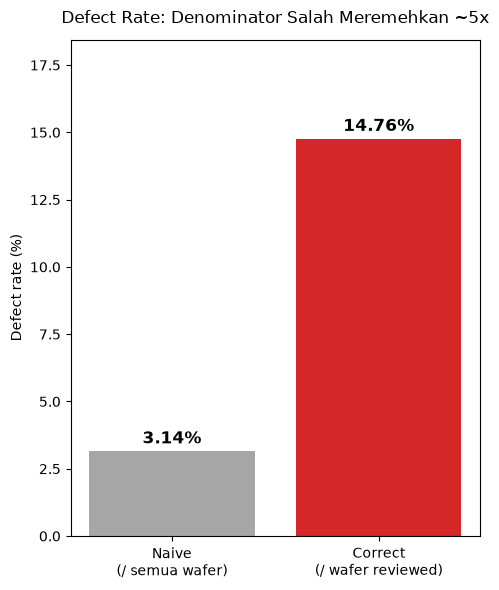

In [11]:
# Naive vs Corrected Defect Rate

n_total = len(df)
n_reviewed_with_defect = (~df['stratify_key'].isin(['unlabeled', 'reviewed_no_defect'])).sum()
n_reviewed_no_defect = (df['stratify_key'] == 'reviewed_no_defect').sum()
n_reviewed = n_reviewed_no_defect + n_reviewed_with_defect

rate_naive = n_reviewed_with_defect / n_total * 100
rate_correct = n_reviewed_with_defect / n_reviewed * 100

print(f"Reviewed with defect : {n_reviewed_with_defect}")
print(f"Naive denominator    : {n_total}     -> {rate_naive:.2f}%")
print(f"Correct denominator  : {n_reviewed}  -> {rate_correct:.2f}%")

plt.figure(figsize=(5, 6))
bars = plt.bar(
    ['Naive\n(/ semua wafer)', 'Correct\n(/ wafer reviewed)'],
    [rate_naive, rate_correct],
    color=['#a6a6a6', '#d62728'],
)
for bar, val in zip(bars, [rate_naive, rate_correct]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.ylabel('Defect rate (%)')
plt.title('Defect Rate: Denominator Salah Meremehkan ~5x', fontsize=12, pad=12)
plt.ylim(0, max(rate_naive, rate_correct) * 1.25)
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/defect_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()